In [ ]:
Supply_Chain_Demand_Forecasting_Prophet

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [1]:
from google.colab import files
import pandas as pd
uploaded = files.upload()


Saving sales_data_clean.csv to sales_data_clean.csv


Category Analysis Results:
                  Quantity  Total_Amount
Product_Category                        
Electronics           1379    2328806.81
Home & Garden         1353     908348.86
Sports                1519     754563.56
Fashion               1411     375214.93
Toys                  1368     223142.48
Beauty                1424     156584.74
Food                  1355      96138.67
Books                 1291      72744.52


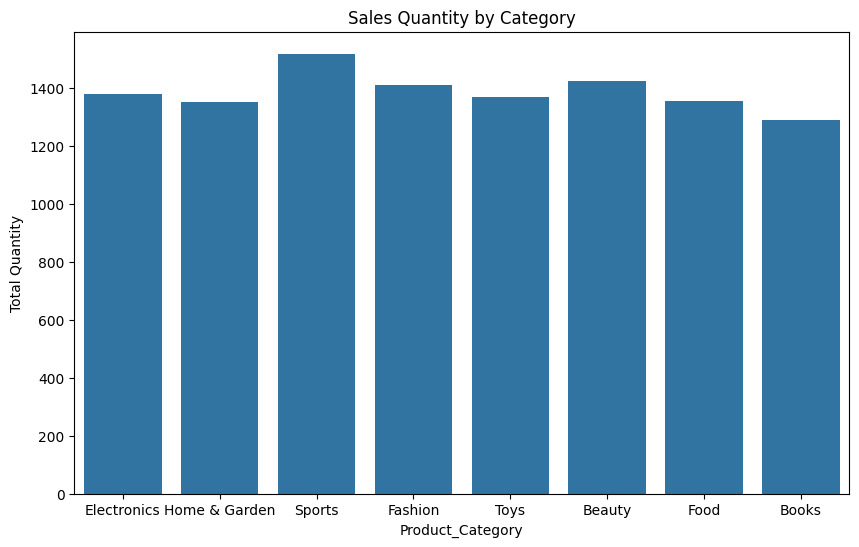

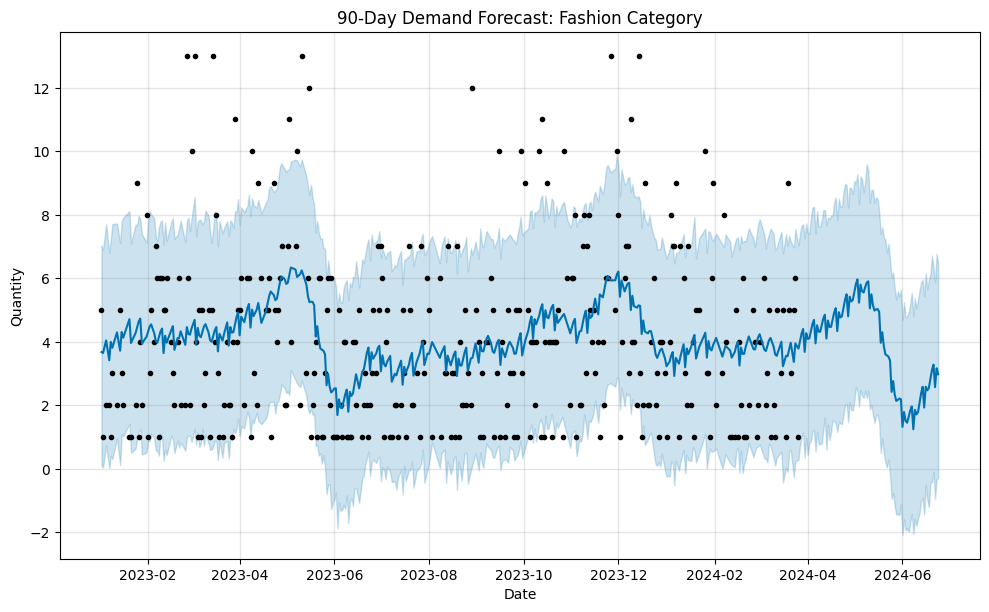

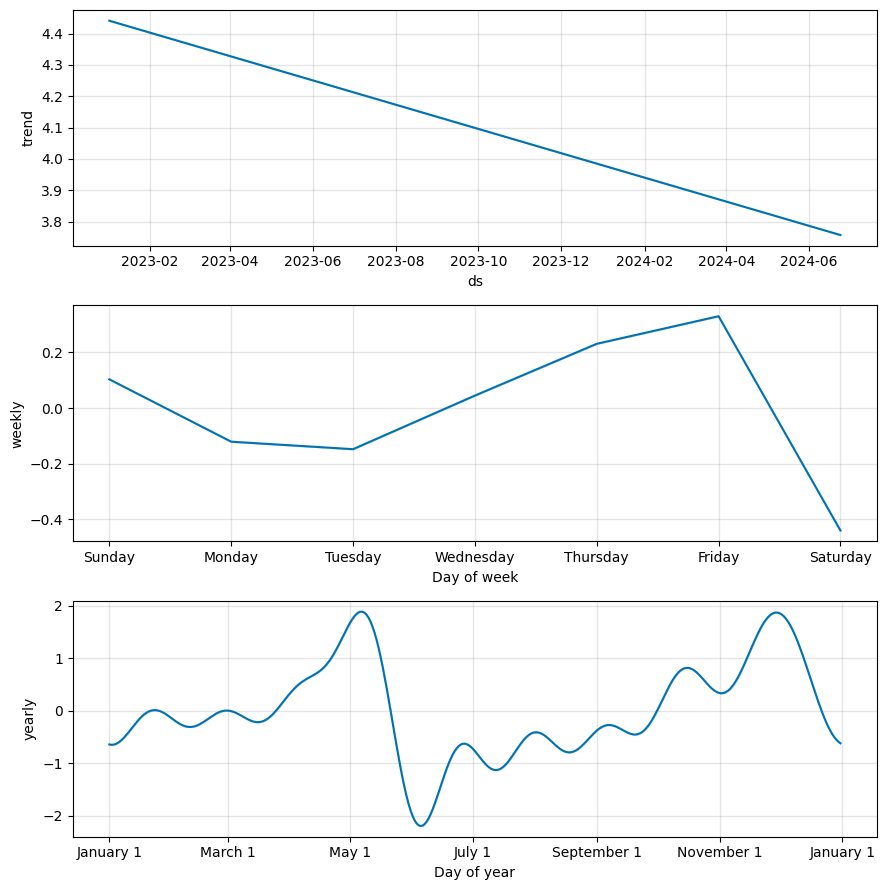

Model Evaluation Metrics:
RMSE: 2.67
R-squared: 0.10


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

CSV files generated and download triggered successfully.


In [11]:
from prophet import Prophet
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
# 1. Load the cleaned dataset
df = pd.read_csv('sales_data_clean.csv')
df['Date'] = pd.to_datetime(df['Date'])

# --- Part 1: Core Supply Chain Transaction Features Analysis (EDA) ---
# [cite: 32] Perform exploratory data analysis (EDA) to understand key trends and patterns.

# Comparison of Sales Quantity and Total Sales by Category
category_analysis = df.groupby('Product_Category').agg({
    'Quantity': 'sum',
    'Total_Amount': 'sum' # Changed 'Total_Sales' to 'Total_Amount'
}).sort_values(by='Total_Amount', ascending=False) # Changed 'Total_Sales' to 'Total_Amount'

print("Category Analysis Results:")
print(category_analysis)

# Average Order Value (AOV) Analysis
category_analysis['AOV'] = category_analysis['Total_Amount'] / category_analysis['Quantity'] # Changed 'Total_Sales' to 'Total_Amount'

# Visualize Core Categories by Quantity
plt.figure(figsize=(10, 6))
sns.barplot(x=category_analysis.index, y=category_analysis['Quantity'])
plt.title('Sales Quantity by Category')
plt.ylabel('Total Quantity')
plt.xlabel('Product_Category')
plt.show()

# --- Part 2: Demand Forecasting using Prophet (Example: Fashion Category) ---
# [cite: 38] Demand forecasting using time series models.

# Filter the target category for forecasting
fashion_df = df[df['Product_Category'] == 'Fashion'].groupby('Date').agg({'Quantity': 'sum'}).reset_index()

# Prepare Prophet format: 'ds' for date, 'y' for target variable
prophet_df = fashion_df.rename(columns={'Date': 'ds', 'Quantity': 'y'})

# Initialize and train the model
# [cite: 58] Train and test the model using appropriate evaluation techniques.
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.fit(prophet_df)

# Forecast for the next 90 days
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

# Plot the forecast results
# [cite: 63] Visualize results through graphs, dashboards, or reports.
fig1 = model.plot(forecast)
plt.title('90-Day Demand Forecast: Fashion Category')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.show()

# Plot seasonal components (Trend, Weekly, Yearly)
fig2 = model.plot_components(forecast)
plt.show()

# --- Part 3: Performance Validation (Justification) ---
# [cite: 56] Support the justification with performance metrics (e.g., accuracy, RMSE, R-squared).

# Calculate fitting accuracy on historical data
y_true = prophet_df['y'].values
y_pred = forecast.iloc[:len(y_true)]['yhat'].values

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"Model Evaluation Metrics:")
print(f"RMSE: {rmse:.2f}")
print(f"R-squared: {r2:.2f}")

# --- Part 4: Export Results to CSV for Submission ---
#  Required Documents include Dataset (CSV, JSON, SQL, etc.)

# 1. Export Category Analysis Results (EDA summary)
category_analysis.to_csv('category_analysis_summary.csv', index=True)

# 2. Export Prophet Forecast Data (Next 90 days)
# We filter key columns: Date, Predicted Quantity, and Confidence Intervals
forecast_output = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(90)
forecast_output.to_csv('fashion_demand_forecast_90days.csv', index=False)

# 3. Trigger automatic download to local machine (Colab only)
from google.colab import files
files.download('category_analysis_summary.csv')
files.download('fashion_demand_forecast_90days.csv')

print("CSV files generated and download triggered successfully.")